# Pixels to Predictions — V5 Fast Colab Notebook

This version is prepared for **Google Colab + Google Drive**.

Main goals:
1. Keep the strong `train + val` LoRA training approach that produced the current best submission.
2. Save all important outputs to Drive so runtime disconnects do not waste training.
3. Reuse a saved adapter automatically when available.
4. Resume training from Drive checkpoints if training was interrupted.
5. Cache the dataset locally in `/content` for faster image loading.
6. Run V5 prompt-stem inference and create conservative/weighted submission files.

Important:
- If a trained adapter already exists in Drive, this notebook skips training and directly runs inference.
- If no adapter exists, it trains once and saves the adapter to Drive.
- Keep your current best `submission_alldata.csv` safe. This notebook compares against it when available.


In [2]:
# ── 0. Install dependencies for Colab ─────────────────────────────
# Run this once in a fresh runtime, then restart runtime before continuing.

!pip uninstall -y transformers tokenizers accelerate peft bitsandbytes -q

!pip install -q --no-cache-dir \
    "transformers==4.51.3" \
    "tokenizers==0.21.1" \
    "accelerate==1.6.0" \
    "peft==0.15.2" \
    "bitsandbytes==0.45.5" \
    "sentencepiece" \
    "protobuf" \
    "pillow"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 209.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 273.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 406.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 413.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 146.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 99.3 MB/s eta 0:00:00


In [3]:
# ── 1. Mount Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [4]:
# ── 2. Imports and runtime check ──────────────────────────────────
import os, json, random, warnings, shutil, subprocess, time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

import transformers, tokenizers, accelerate, peft
import bitsandbytes as bnb

warnings.filterwarnings("ignore")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"transformers: {transformers.__version__}")
print(f"tokenizers: {tokenizers.__version__}")
print(f"accelerate: {accelerate.__version__}")
print(f"peft: {peft.__version__}")
print(f"bitsandbytes: {bnb.__version__}")

# Safe speed settings. These do not change model logic.
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB
transformers: 4.51.3
tokenizers: 0.21.1
accelerate: 1.6.0
peft: 0.15.2
bitsandbytes: 0.45.5


In [5]:
# ── 3. Hyperparameters and control flags ──────────────────────────
SEED                 = 42
MODEL_ID             = "HuggingFaceTB/SmolVLM-500M-Instruct"

# High-resolution inference attempt.
# We are NOT retraining. We are using the trained checkpoint-1557 adapter.
IMG_MAX_SIZE         = 768

NUM_EPOCHS           = 3
PER_DEVICE_BATCH     = 1
GRAD_ACCUM_STEPS     = 8
LEARNING_RATE        = 1.5e-4
WARMUP_RATIO         = 0.05
WEIGHT_DECAY         = 0.01
LORA_R               = 8
LORA_ALPHA           = 32
LORA_DROPOUT         = 0.05
CHOICE_LETTERS       = "ABCDEFGHIJ"

# Runtime / speed controls.
# IMPORTANT: no retraining now.
FORCE_RETRAIN                      = False
SKIP_TRAINING_IF_ADAPTER_EXISTS    = True
USE_LOCAL_DATA_CACHE               = True
CLEAR_OLD_INFERENCE_CACHE_ON_TRAIN = False

# Use checkpoint-1557 directly.
# This was the checkpoint that improved your score earlier.
ADAPTER_DIR_OVERRIDE = "/content/drive/MyDrive/pixels-to-predictions/outputs_v5_fast_colab/checkpoints/checkpoint-1557"
ALLOW_V5_ADAPTER_AUTO_DISCOVERY = False

# With local /content cache, 2 workers are okay.
DATALOADER_NUM_WORKERS = 2 if USE_LOCAL_DATA_CACHE else 0

# New run name so it does NOT reuse old 512px cached scores.
RUN_NAME = f"smolvlm_v5_seed{SEED}_img{IMG_MAX_SIZE}_ep{NUM_EPOCHS}_lr{LEARNING_RATE}_r{LORA_R}_ckpt1557_highres768"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Config set.")
print("RUN_NAME:", RUN_NAME)
print("IMG_MAX_SIZE:", IMG_MAX_SIZE)
print("FORCE_RETRAIN:", FORCE_RETRAIN)
print("SKIP_TRAINING_IF_ADAPTER_EXISTS:", SKIP_TRAINING_IF_ADAPTER_EXISTS)
print("USE_LOCAL_DATA_CACHE:", USE_LOCAL_DATA_CACHE)
print("DATALOADER_NUM_WORKERS:", DATALOADER_NUM_WORKERS)
print("ADAPTER_DIR_OVERRIDE:", ADAPTER_DIR_OVERRIDE)
print("ALLOW_V5_ADAPTER_AUTO_DISCOVERY:", ALLOW_V5_ADAPTER_AUTO_DISCOVERY)

Config set.
RUN_NAME: smolvlm_v5_seed42_img768_ep3_lr0.00015_r8_ckpt1557_highres768
IMG_MAX_SIZE: 768
FORCE_RETRAIN: False
SKIP_TRAINING_IF_ADAPTER_EXISTS: True
USE_LOCAL_DATA_CACHE: True
DATALOADER_NUM_WORKERS: 2
ADAPTER_DIR_OVERRIDE: /content/drive/MyDrive/pixels-to-predictions/outputs_v5_fast_colab/checkpoints/checkpoint-1557
ALLOW_V5_ADAPTER_AUTO_DISCOVERY: False


In [6]:
# ── 4. Paths — Colab Google Drive + local cache ───────────────────
DRIVE_DATA_DIR = Path("/content/drive/MyDrive/pixels-to-predictions")
assert DRIVE_DATA_DIR.exists(), f"Drive data folder not found: {DRIVE_DATA_DIR}"

DRIVE_IMAGE_DIR = DRIVE_DATA_DIR / "images"
if (DRIVE_IMAGE_DIR / "images").exists():
    DRIVE_IMAGE_DIR = DRIVE_IMAGE_DIR / "images"

required_drive_paths = [
    DRIVE_DATA_DIR / "train.csv",
    DRIVE_DATA_DIR / "val.csv",
    DRIVE_DATA_DIR / "test.csv",
    DRIVE_DATA_DIR / "sample_submission.csv",
    DRIVE_IMAGE_DIR,
]
for path in required_drive_paths:
    assert path.exists(), f"Missing path: {path}"

# Persistent output folder in Drive.
OUTPUT_DIR = DRIVE_DATA_DIR / "outputs_v5_fast_colab"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Main location for newly trained adapter.
DEFAULT_ADAPTER_DIR = OUTPUT_DIR / "smolvlm_adapter"

# Fast path: reuse a known saved V5 adapter if it exists.
# This saves hours without changing inference logic.
if ADAPTER_DIR_OVERRIDE is not None:
    ADAPTER_DIR = Path(ADAPTER_DIR_OVERRIDE)
elif ALLOW_V5_ADAPTER_AUTO_DISCOVERY:
    adapter_candidates = [
        DEFAULT_ADAPTER_DIR,
        DRIVE_DATA_DIR / "outputs_v5" / "smolvlm_adapter",          # previous V5 path
        DRIVE_DATA_DIR / "outputs_v5_fast_colab" / "smolvlm_adapter",
    ]
    found = None
    for cand in adapter_candidates:
        if (cand / "adapter_config.json").exists():
            found = cand
            break
    ADAPTER_DIR = found if found is not None else DEFAULT_ADAPTER_DIR
else:
    ADAPTER_DIR = DEFAULT_ADAPTER_DIR

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Optional local cache for speed. Outputs still save to Drive.
LOCAL_DATA_DIR = Path("/content/pixels-to-predictions-cache")
LOCAL_IMAGE_DIR = LOCAL_DATA_DIR / "images"

def sync_dir_fast(src: Path, dst: Path):
    dst.mkdir(parents=True, exist_ok=True)
    try:
        subprocess.run(["rsync", "-a", str(src) + "/", str(dst) + "/"], check=True)
    except Exception:
        files = [p for p in src.rglob("*") if p.is_file()]
        for p in tqdm(files, desc=f"Caching {src.name}"):
            rel = p.relative_to(src)
            out = dst / rel
            out.parent.mkdir(parents=True, exist_ok=True)
            if not out.exists() or out.stat().st_size != p.stat().st_size:
                shutil.copy2(p, out)

if USE_LOCAL_DATA_CACHE:
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

    # Copy CSVs and best submission reference if present.
    for name in ["train.csv", "val.csv", "test.csv", "sample_submission.csv", "submission_alldata.csv"]:
        src = DRIVE_DATA_DIR / name
        if src.exists():
            dst = LOCAL_DATA_DIR / name
            if (not dst.exists()) or dst.stat().st_size != src.stat().st_size:
                shutil.copy2(src, dst)

    print("Caching images to local runtime storage. First run may take a few minutes.")
    sync_dir_fast(DRIVE_IMAGE_DIR, LOCAL_IMAGE_DIR)

    DATA_DIR = LOCAL_DATA_DIR
    IMAGE_DIR = LOCAL_IMAGE_DIR
else:
    DATA_DIR = DRIVE_DATA_DIR
    IMAGE_DIR = DRIVE_IMAGE_DIR

print(f"Drive data dir : {DRIVE_DATA_DIR}  (exists: {DRIVE_DATA_DIR.exists()})")
print(f"Data dir used  : {DATA_DIR}  (exists: {DATA_DIR.exists()})")
print(f"Image dir used : {IMAGE_DIR}  (exists: {IMAGE_DIR.exists()})")
print(f"Output dir     : {OUTPUT_DIR}")
print(f"Adapter dir    : {ADAPTER_DIR}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")

print("\\nData files:")
for name in ["train.csv", "val.csv", "test.csv", "sample_submission.csv"]:
    print(name, "->", (DATA_DIR / name).exists())
print("Best CSV available:", (DRIVE_DATA_DIR / "submission_alldata.csv").exists() or (DATA_DIR / "submission_alldata.csv").exists())


Caching images to local runtime storage. First run may take a few minutes.


KeyboardInterrupt: 

In [ ]:
# # ── Check saved checkpoints for possible better model ─────────────
# from pathlib import Path

# print("OUTPUT_DIR:", OUTPUT_DIR)
# print("ADAPTER_DIR:", ADAPTER_DIR)
# print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

# possible_checkpoint_roots = [
#     OUTPUT_DIR,
#     CHECKPOINT_DIR,
#     OUTPUT_DIR / "trainer_outputs",
# ]

# all_checkpoints = []

# for root in possible_checkpoint_roots:
#     if root.exists():
#         found = sorted(root.rglob("checkpoint-*"))
#         all_checkpoints.extend(found)

# all_checkpoints = sorted(list(set(all_checkpoints)))

# print("\nFound checkpoints:")
# if len(all_checkpoints) == 0:
#     print("No checkpoints found.")
# else:
#     for i, ckpt in enumerate(all_checkpoints):
#         print(f"{i}: {ckpt}")

OUTPUT_DIR: /content/drive/MyDrive/pixels-to-predictions/outputs_v5_fast_colab
ADAPTER_DIR: /content/drive/MyDrive/pixels-to-predictions/outputs_v5_fast_colab/checkpoints/checkpoint-1557
CHECKPOINT_DIR: /content/drive/MyDrive/pixels-to-predictions/outputs_v5_fast_colab/checkpoints

Found checkpoints:
0: /content/drive/MyDrive/pixels-to-predictions/outputs_v5_fast_colab/checkpoints/checkpoint-1400
1: /content/drive/MyDrive/pixels-to-predictions/outputs_v5_fast_colab/checkpoints/checkpoint-1557


In [ ]:
# ── 5. Load data ──────────────────────────────────────────────────
def parse_choices(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    try:
        return json.loads(x)
    except Exception:
        import ast
        return ast.literal_eval(x)

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(parse_choices)

# Combine train + val for final training. This is key to the current best approach.
all_train_df = pd.concat([train_df, val_df], ignore_index=True)

assert len(test_df) == len(sample_submission), "test.csv and sample_submission.csv row count mismatch"

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Combined: {len(all_train_df):,} | Test: {len(test_df):,}")
print("Test choice counts:")
print(test_df["choices"].apply(len).value_counts().sort_index())
display(train_df.head(2))


Train: 3,109 | Val: 1,048 | Combined: 4,157 | Test: 1,008
Test choice counts:
choices
2    272
3    438
4    260
5     38
Name: count, dtype: int64


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


Indexed 15,495 image entries
Sample image path: /content/pixels-to-predictions-cache/images/train/train_07667.png


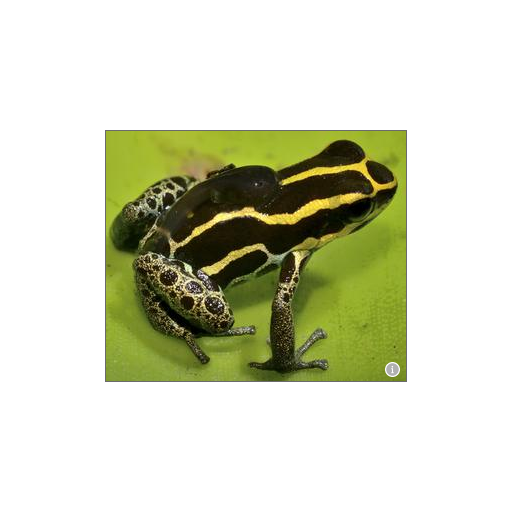

In [ ]:
# ── 6. Image handling ─────────────────────────────────────────────
IMAGE_EXTS  = {".png", ".jpg", ".jpeg", ".webp"}
IMAGE_INDEX = {}

for p in IMAGE_DIR.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
        IMAGE_INDEX[p.name] = p
        IMAGE_INDEX[str(p.relative_to(IMAGE_DIR))] = p
        try:
            IMAGE_INDEX[str(p.relative_to(DATA_DIR))] = p
        except ValueError:
            pass

print(f"Indexed {len(IMAGE_INDEX):,} image entries")

def resolve_image_path(row):
    raw = str(row["image_path"])
    raw_obj = Path(raw)

    candidates = [
        DATA_DIR / raw,
        IMAGE_DIR / raw,
        IMAGE_DIR / raw_obj.name,
        DATA_DIR / "images" / raw_obj.name,
    ]
    for c in candidates:
        if c.exists():
            return c

    for k in [raw, raw_obj.name, str(Path(raw).name)]:
        if k in IMAGE_INDEX:
            return IMAGE_INDEX[k]

    raise FileNotFoundError(f"Cannot find image for CSV path: {raw}")

def load_image(row):
    img = Image.open(resolve_image_path(row)).convert("RGB")
    img.thumbnail((IMG_MAX_SIZE, IMG_MAX_SIZE), Image.Resampling.BICUBIC)

    canvas = Image.new("RGB", (IMG_MAX_SIZE, IMG_MAX_SIZE), "white")
    canvas.paste(img, ((IMG_MAX_SIZE - img.width) // 2, (IMG_MAX_SIZE - img.height) // 2))
    return canvas

# Quick image sanity check
sample_path = resolve_image_path(all_train_df.iloc[0])
print("Sample image path:", sample_path)
display(load_image(all_train_df.iloc[0]))


In [ ]:
# ── Prompt builder ─────────────────────────────────────────────
def clean_text(x):
    if x is None or pd.isna(x): return ''
    return ' '.join(str(x).replace('\n', ' ').split())

def build_prompt(row, include_answer=False):
    parts = ['<image>', 'Look at the image and answer the science multiple-choice question.']

    subject = clean_text(row.get('subject', ''))
    grade   = clean_text(row.get('grade', ''))
    if subject or grade:
        parts.append(f'Subject: {subject}  Grade: {grade}')

    lecture = clean_text(row.get('lecture', ''))
    hint    = clean_text(row.get('hint', ''))
    if lecture: parts.append(f'Background: {lecture}')
    if hint:    parts.append(f'Hint: {hint}')

    parts.append(f'Question: {clean_text(row["question"])}')
    choices_text = '\n'.join(
        [f'{CHOICE_LETTERS[i]}. {clean_text(c)}' for i, c in enumerate(row['choices'])]
    )
    parts.append(f'Choices:\n{choices_text}')
    parts.append('The correct answer is:')

    prompt = '\n\n'.join(parts)
    if include_answer:
        prompt += ' ' + CHOICE_LETTERS[int(row['answer'])]
    return prompt

# Quick sanity check
sample = all_train_df.iloc[0]
print(build_prompt(sample)[:400], '...')

<image>

Look at the image and answer the science multiple-choice question.

Subject: natural science  Grade: grade8

Background: Animals increase their reproductive success when they have offspring that survive to reproduce. Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For exampl ...


In [ ]:
# ── 8. Load SmolVLM + existing adapter or fresh QLoRA ─────────────
from transformers import AutoProcessor, AutoModelForVision2Seq, BitsAndBytesConfig
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
)
base_model.config.use_cache = False

adapter_exists = (ADAPTER_DIR / "adapter_config.json").exists()
TRAINING_REQUIRED = True

if adapter_exists and SKIP_TRAINING_IF_ADAPTER_EXISTS and not FORCE_RETRAIN:
    print("Found trained adapter in Drive. Loading it and skipping training:")
    print(ADAPTER_DIR)
    model = PeftModel.from_pretrained(base_model, ADAPTER_DIR, is_trainable=False)
    TRAINING_REQUIRED = False
else:
    if FORCE_RETRAIN:
        print("FORCE_RETRAIN=True, creating a fresh LoRA adapter.")
    else:
        print("No saved adapter found. Creating a fresh LoRA adapter for training.")

    base_model = prepare_model_for_kbit_training(base_model)

    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
        task_type=TaskType.CAUSAL_LM,
    )

    model = get_peft_model(base_model, lora_config)
    TRAINING_REQUIRED = True

model.print_trainable_parameters()

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {n_trainable:,}  (cap: 5,000,000)")
if TRAINING_REQUIRED:
    assert n_trainable <= 5_000_000, f"Exceeds 5M cap: {n_trainable:,}"
else:
    print("Training skipped mode: trainable params can be 0 because adapter is loaded for inference.")


In [ ]:
# ── Dataset + collator ─────────────────────────────────────────
class ScienceQADataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {'row': row, 'image': load_image(row)}

def train_collate_fn(batch):
    images  = [b['image'] for b in batch]
    prompts = [build_prompt(b['row'], include_answer=False) for b in batch]
    answers = [' ' + CHOICE_LETTERS[int(b['row']['answer'])] for b in batch]
    eos     = processor.tokenizer.eos_token or ''
    full_texts = [p + a + eos for p, a in zip(prompts, answers)]

    full   = processor(text=full_texts, images=images, padding=True, return_tensors='pt')
    p_only = processor(text=prompts,    images=images, padding=True, return_tensors='pt')

    labels = full['input_ids'].clone()
    labels[full['attention_mask'] == 0] = -100
    for i in range(len(batch)):
        prompt_len = int(p_only['attention_mask'][i].sum().item())
        labels[i, :prompt_len] = -100

    full['labels'] = labels
    return full

train_dataset = ScienceQADataset(all_train_df)
print(f'Training samples: {len(train_dataset):,}')

In [ ]:
# ── 10. Training / resume / skip if adapter exists ────────────────
from transformers import Trainer, TrainingArguments, TrainerCallback

class SaveCallback(TrainerCallback):
    """Mark each checkpoint so we can safely resume."""
    def on_save(self, args, state, control, **kwargs):
        ckpt = Path(args.output_dir) / f"checkpoint-{state.global_step}"
        ckpt.mkdir(parents=True, exist_ok=True)
        (ckpt / "plain_lora.txt").write_text("true")

def checkpoint_step(path: Path):
    try:
        return int(path.name.split("-")[-1])
    except Exception:
        return -1

if not TRAINING_REQUIRED:
    print("Training skipped because a saved adapter was loaded from Drive.")
    print("Adapter in use:", ADAPTER_DIR)
else:
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    # Resume from last checkpoint if it exists.
    existing = sorted(CHECKPOINT_DIR.glob("checkpoint-*"), key=checkpoint_step)
    resume_from = None

    if existing:
        last = existing[-1]
        if (last / "plain_lora.txt").exists():
            resume_from = str(last)
            print(f"Resuming training from: {resume_from}")
        else:
            # Avoid loading incompatible/partial checkpoints.
            for c in existing:
                shutil.rmtree(c, ignore_errors=True)
            print("Cleared old incompatible checkpoints.")

    if not resume_from:
        print("Starting training from scratch.")

    training_args = TrainingArguments(
        output_dir=str(CHECKPOINT_DIR),
        per_device_train_batch_size=PER_DEVICE_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        lr_scheduler_type="cosine",
        optim="paged_adamw_8bit",
        fp16=torch.cuda.is_available(),
        bf16=False,
        gradient_checkpointing=True,
        logging_steps=20,
        save_strategy="steps",
        save_steps=200,
        save_total_limit=2,
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=DATALOADER_NUM_WORKERS,
        dataloader_pin_memory=True,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=train_collate_fn,
        callbacks=[SaveCallback()],
    )

    trainer.train(resume_from_checkpoint=resume_from)

    model.save_pretrained(ADAPTER_DIR)
    processor.save_pretrained(ADAPTER_DIR)
    print(f"Adapter saved to: {ADAPTER_DIR}")

    # If the model was retrained, remove old inference score caches so we do not reuse stale predictions.
    if CLEAR_OLD_INFERENCE_CACHE_ON_TRAIN:
        for p in OUTPUT_DIR.glob("test_scores_v5_prompt_stems*.json"):
            print("Removing stale inference cache:", p)
            p.unlink()


In [ ]:
# ── 11. V5 inference — conservative prompt-stem ensemble ──────────
# Scores several natural prompt endings, always with a letter-only answer.
# This does not retrain the model. It caches scores to Drive so disconnects do not waste inference time.

model.eval()

def move_to_device(batch):
    dev = next(model.parameters()).device
    return {k: v.to(dev) if torch.is_tensor(v) else v for k, v in batch.items()}

def build_prompt_stem(row, final_line="The correct answer is:"):
    parts = ["<image>", "Look at the image and answer the science multiple-choice question."]

    subject = clean_text(row.get("subject", ""))
    grade   = clean_text(row.get("grade", ""))
    if subject or grade:
        parts.append(f"Subject: {subject}  Grade: {grade}")

    lecture = clean_text(row.get("lecture", ""))
    hint    = clean_text(row.get("hint", ""))
    if lecture:
        parts.append(f"Background: {lecture}")
    if hint:
        parts.append(f"Hint: {hint}")

    parts.append(f"Question: {clean_text(row['question'])}")
    choices_text = "\n".join(
        [f"{CHOICE_LETTERS[i]}. {clean_text(c)}" for i, c in enumerate(row["choices"])]
    )
    parts.append(f"Choices:\n{choices_text}")
    parts.append(final_line)

    return "\n\n".join(parts)

@torch.inference_mode()
def score_row_with_stem(row, final_line):
    image  = load_image(row)
    prompt = build_prompt_stem(row, final_line=final_line)
    n      = len(row["choices"])

    texts  = [prompt + " " + CHOICE_LETTERS[i] for i in range(n)]
    imgs   = [image] * n

    # No truncation. Truncation breaks SmolVLM image-token alignment.
    enc  = processor(text=texts, images=imgs, padding=True, return_tensors="pt")
    penc = processor(text=[prompt] * n, images=imgs, padding=True, return_tensors="pt")
    enc  = move_to_device(enc)

    out    = model(**enc)
    logits = out.logits.float().cpu()
    ids    = enc["input_ids"].cpu()
    mask   = enc["attention_mask"].cpu()
    pmask  = penc["attention_mask"].cpu()

    scores = []
    for i in range(n):
        tlen = int(mask[i].sum().item())
        plen = int(pmask[i].sum().item())
        if plen >= tlen:
            scores.append(1e9)
            continue

        tgt = ids[i, plen:tlen]
        lp  = F.log_softmax(logits[i, plen-1:tlen-1, :], dim=-1)
        nll = -lp[torch.arange(len(tgt)), tgt].mean().item()
        scores.append(nll)

    return np.array(scores, dtype=np.float32)

def normalize_scores(scores):
    scores = np.array(scores, dtype=np.float32)
    return (scores - scores.mean()) / (scores.std() + 1e-6)

# Keep this conservative. V4 dropped because too many unnatural modes were added.
PROMPT_STEMS_V5 = {
    "base":    "The correct answer is:",
    "answer":  "Answer:",
    "option":  "The correct option is:",
    "final":   "Final answer:",
}

TEST_SCORES_CKPT = OUTPUT_DIR / f"test_scores_v5_prompt_stems_{RUN_NAME}.json"
test_scores_v5 = {}

if TEST_SCORES_CKPT.exists():
    with open(TEST_SCORES_CKPT) as f:
        test_scores_v5 = json.load(f)

    # Keep only valid ids and complete mode sets.
    valid_ids = set(test_df["id"].astype(str))
    required_modes = set(PROMPT_STEMS_V5.keys())
    test_scores_v5 = {
        k: v for k, v in test_scores_v5.items()
        if k in valid_ids and required_modes.issubset(set(v.keys()))
    }
    print(f"Resuming V5 scores: {len(test_scores_v5)}/{len(test_df)} done")
else:
    print("Starting fresh V5 scoring")

for idx in tqdm(range(len(test_df)), desc="Scoring test V5"):
    row = test_df.iloc[idx]
    row_id = str(row["id"])

    if row_id in test_scores_v5:
        continue

    mode_scores = {}
    for mode_name, final_line in PROMPT_STEMS_V5.items():
        mode_scores[mode_name] = score_row_with_stem(row, final_line).tolist()

    test_scores_v5[row_id] = mode_scores

    if len(test_scores_v5) % 10 == 0:
        with open(TEST_SCORES_CKPT, "w") as f:
            json.dump(test_scores_v5, f)

with open(TEST_SCORES_CKPT, "w") as f:
    json.dump(test_scores_v5, f)

print("V5 scoring complete!")
print("Cache saved to:", TEST_SCORES_CKPT)


In [ ]:
# ── V6A: Generate threshold variants from existing V5 cached scores ──────────
# No retraining. No new model inference if test_scores_v5 already exists.
# This creates multiple safer/aggressive variants around the current best V5 logic.

import numpy as np
import pandas as pd

def second_margin(scores):
    scores = np.array(scores, dtype=np.float32)
    sorted_scores = np.sort(scores)

    if len(sorted_scores) < 2:
        return 0.0

    # Since lower score is better, margin = second best - best
    return float(sorted_scores[1] - sorted_scores[0])


def predict_from_v5_scores_threshold(
    mode_scores,
    vote_needed=3,
    base_margin_max=0.25,
    combined_margin_min=0.08,
    w_answer=0.18,
    w_option=0.15,
    w_final=0.10
):
    z_base   = normalize_scores(mode_scores["base"])
    z_answer = normalize_scores(mode_scores["answer"])
    z_option = normalize_scores(mode_scores["option"])
    z_final  = normalize_scores(mode_scores["final"])

    base_pred = int(np.argmin(z_base))

    combined = (
        1.00 * z_base +
        w_answer * z_answer +
        w_option * z_option +
        w_final * z_final
    )

    weighted_pred = int(np.argmin(combined))

    variant_preds = [
        int(np.argmin(z_base)),
        int(np.argmin(z_answer)),
        int(np.argmin(z_option)),
        int(np.argmin(z_final)),
    ]

    alt_votes = sum(p == weighted_pred for p in variant_preds)
    base_margin = second_margin(z_base)
    combined_margin = second_margin(combined)

    pred = base_pred

    if (
        weighted_pred != base_pred
        and alt_votes >= vote_needed
        and base_margin < base_margin_max
        and combined_margin > combined_margin_min
    ):
        pred = weighted_pred

    return pred


def build_threshold_submission(
    name,
    vote_needed,
    base_margin_max,
    combined_margin_min,
    w_answer=0.18,
    w_option=0.15,
    w_final=0.10
):
    preds = []

    for row_id in test_df["id"].astype(str):
        preds.append(
            predict_from_v5_scores_threshold(
                test_scores_v5[row_id],
                vote_needed=vote_needed,
                base_margin_max=base_margin_max,
                combined_margin_min=combined_margin_min,
                w_answer=w_answer,
                w_option=w_option,
                w_final=w_final,
            )
        )

    sub = pd.DataFrame({
        "id": test_df["id"].astype(str),
        "answer": np.array(preds, dtype=int),
    })

    assert list(sub.columns) == ["id", "answer"]
    assert len(sub) == len(test_df)
    assert sub["id"].is_unique
    assert sub["answer"].isna().sum() == 0

    for pred, choices in zip(sub["answer"], test_df["choices"]):
        assert 0 <= int(pred) < len(choices), f"{name}: invalid pred {pred}"

    path = OUTPUT_DIR / f"{name}.csv"
    sub.to_csv(path, index=False)

    print("\nSaved:", path)
    print(sub["answer"].value_counts().sort_index())

    if "submission_v5_conservative" in globals():
        diff = (sub["answer"].values != submission_v5_conservative["answer"].values).sum()
        print("Diff vs V5 conservative:", diff)

    if "best_path" in globals() and best_path is not None:
        best_df = pd.read_csv(best_path)
        merged = best_df.merge(sub, on="id", suffixes=("_best", "_new"))
        diff_best = (merged["answer_best"].astype(int) != merged["answer_new"].astype(int)).sum()
        print("Diff vs submission_alldata/best:", diff_best)

    return sub, path


# Very safe: fewer flips than current conservative
sub_v6_safe, path_v6_safe = build_threshold_submission(
    name="submission_v6_safe_threshold",
    vote_needed=4,
    base_margin_max=0.18,
    combined_margin_min=0.12,
)

# Moderate: around current V5 but slightly more selective
sub_v6_moderate, path_v6_moderate = build_threshold_submission(
    name="submission_v6_moderate_threshold",
    vote_needed=3,
    base_margin_max=0.22,
    combined_margin_min=0.10,
)

# Aggressive: more flips, higher risk, possible higher gain
sub_v6_aggressive, path_v6_aggressive = build_threshold_submission(
    name="submission_v6_aggressive_threshold",
    vote_needed=3,
    base_margin_max=0.35,
    combined_margin_min=0.05,
)

print("\nDownload these manually from Drive or use files.download one by one.")
print(path_v6_safe)
print(path_v6_moderate)
print(path_v6_aggressive)

In [ ]:
# ── 12. Build V5 submissions and compare with best CSV ────────────

def second_margin(z):
    z = np.array(z, dtype=np.float32)
    if len(z) < 2:
        return 0.0
    s = np.sort(z)
    return float(s[1] - s[0])

def predict_from_v5_scores(mode_scores):
    z_base   = normalize_scores(mode_scores["base"])
    z_answer = normalize_scores(mode_scores["answer"])
    z_option = normalize_scores(mode_scores["option"])
    z_final  = normalize_scores(mode_scores["final"])

    base_pred = int(np.argmin(z_base))

    # Weighted version. More aggressive.
    combined = (
        1.00 * z_base +
        0.18 * z_answer +
        0.15 * z_option +
        0.10 * z_final
    )
    weighted_pred = int(np.argmin(combined))

    # Conservative version. Only flips the base answer when base is uncertain
    # and other prompt stems strongly agree.
    variant_preds = [
        int(np.argmin(z_base)),
        int(np.argmin(z_answer)),
        int(np.argmin(z_option)),
        int(np.argmin(z_final)),
    ]

    alt_votes = sum(p == weighted_pred for p in variant_preds)
    base_margin = second_margin(z_base)
    combined_margin = second_margin(combined)

    conservative_pred = base_pred
    if (
        weighted_pred != base_pred
        and alt_votes >= 3
        and base_margin < 0.25
        and combined_margin > 0.08
    ):
        conservative_pred = weighted_pred

    return base_pred, weighted_pred, conservative_pred

base_preds = []
weighted_preds = []
conservative_preds = []

missing_ids = []
for row_id in test_df["id"].astype(str):
    if row_id not in test_scores_v5:
        missing_ids.append(row_id)
        continue
    b, w, c = predict_from_v5_scores(test_scores_v5[row_id])
    base_preds.append(b)
    weighted_preds.append(w)
    conservative_preds.append(c)

assert not missing_ids, f"Missing V5 scores for ids: {missing_ids[:5]}"

submission_base_recomputed = pd.DataFrame({
    "id": test_df["id"].astype(str),
    "answer": np.array(base_preds, dtype=int),
})

submission_v5_weighted = pd.DataFrame({
    "id": test_df["id"].astype(str),
    "answer": np.array(weighted_preds, dtype=int),
})

submission_v5_conservative = pd.DataFrame({
    "id": test_df["id"].astype(str),
    "answer": np.array(conservative_preds, dtype=int),
})

for name, sub in [
    ("base_recomputed", submission_base_recomputed),
    ("v5_weighted", submission_v5_weighted),
    ("v5_conservative", submission_v5_conservative),
]:
    assert list(sub.columns) == ["id", "answer"]
    assert len(sub) == len(test_df)
    assert sub["id"].is_unique
    assert sub["answer"].isna().sum() == 0
    for pred, choices in zip(sub["answer"], test_df["choices"]):
        assert 0 <= int(pred) < len(choices), f"{name}: invalid pred {pred}"

base_path = OUTPUT_DIR / "submission_base_recomputed.csv"
v5_weighted_path = OUTPUT_DIR / "submission_v5_prompt_stem_weighted.csv"
v5_conservative_path = OUTPUT_DIR / "submission_v5_prompt_stem_conservative.csv"

submission_base_recomputed.to_csv(base_path, index=False)
submission_v5_weighted.to_csv(v5_weighted_path, index=False)
submission_v5_conservative.to_csv(v5_conservative_path, index=False)

print("Saved:")
print(base_path)
print(v5_weighted_path)
print(v5_conservative_path)

print("\nAnswer distribution: V5 conservative")
print(submission_v5_conservative["answer"].value_counts().sort_index())

print("\nPrediction distribution by number of choices: V5 conservative")
check_df = test_df.copy()
check_df["pred"] = submission_v5_conservative["answer"].astype(int).values
check_df["num_choices"] = check_df["choices"].apply(len)
print(pd.crosstab(check_df["num_choices"], check_df["pred"]))

# Optional comparison against current best file.
possible_best_paths = [
    DATA_DIR / "submission_alldata.csv",
    DRIVE_DATA_DIR / "submission_alldata.csv",
    OUTPUT_DIR / "submission_alldata.csv",
]

best_path = None
for p in possible_best_paths:
    if p.exists():
        best_path = p
        break

if best_path is not None:
    print("\nComparing against:", best_path)
    best_sub = pd.read_csv(best_path)
    for label, sub in [
        ("base_recomputed", submission_base_recomputed),
        ("v5_weighted", submission_v5_weighted),
        ("v5_conservative", submission_v5_conservative),
    ]:
        merged = best_sub.merge(sub, on="id", suffixes=("_best", "_new"))
        changed = (merged["answer_best"].astype(int) != merged["answer_new"].astype(int)).mean()
        print(f"{label}: changed vs best CSV = {changed:.2%}")
else:
    print("\nBest CSV not found. Put submission_alldata.csv inside your Drive dataset folder to compare changes.")

# Colab download helper. Submit conservative first, then weighted only if you want another attempt.
try:
    from google.colab import files
    print("\nDownloading conservative submission first:")
    files.download(str(v5_conservative_path))
except Exception:
    print("Download manually from:", v5_conservative_path)
    print("Weighted file:", v5_weighted_path)


In [ ]:
from google.colab import files
from pathlib import Path

weighted_files = sorted(OUTPUT_DIR.glob("*weighted*.csv"))

print("Weighted files found:")
for f in weighted_files:
    print(f)

latest_weighted = weighted_files[-1]
print("Downloading:", latest_weighted)

files.download(str(latest_weighted))